In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [26]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


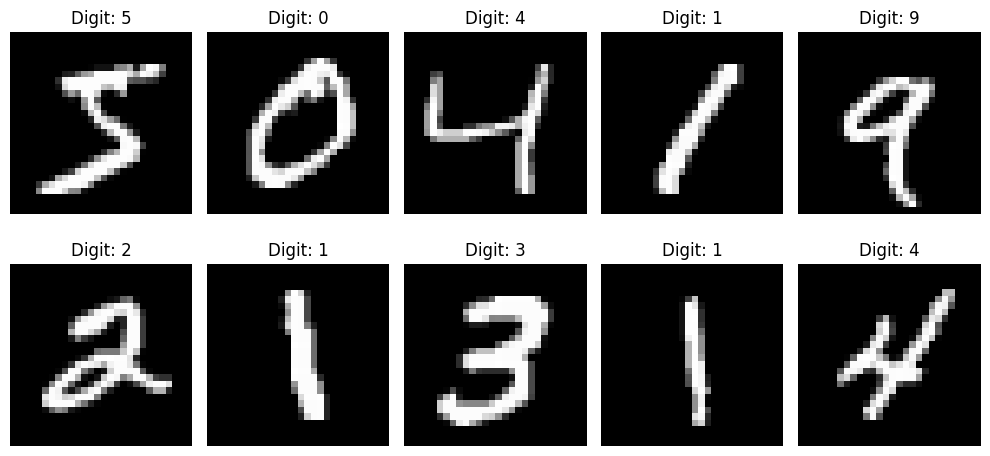

In [27]:
# Display sample handwritten digits

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Digit: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [28]:
# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape images for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
Training labels shape: (60000, 10)


In [29]:
# Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compile the CNN model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [31]:
# Train the CNN model

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9124 - loss: 0.2863 - val_accuracy: 0.9832 - val_loss: 0.0607
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9694 - loss: 0.1025 - val_accuracy: 0.9885 - val_loss: 0.0418
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9785 - loss: 0.0729 - val_accuracy: 0.9897 - val_loss: 0.0347
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.9821 - loss: 0.0603 - val_accuracy: 0.9892 - val_loss: 0.0351
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9851 - loss: 0.0498 - val_accuracy: 0.9910 - val_loss: 0.0321
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9868 - loss: 0.0439 - val_accuracy: 0.9915 - val_loss: 0.0331
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.9915 - val_loss: 0.0326
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9891 - loss: 0.0332 - 

In [32]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9915 - loss: 0.0276
Test Loss: 0.027578171342611313
Test Accuracy: 0.9915000200271606
Test Accuracy (%): 99.15000200271606


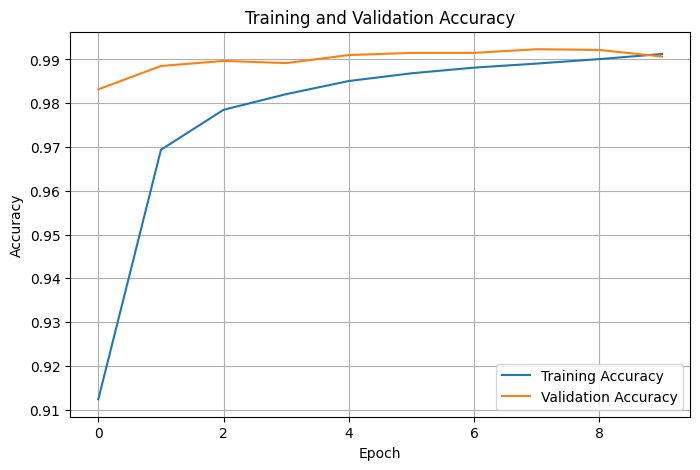

In [33]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [34]:
# Make predictions on test images

predictions = model.predict(X_test)

# Convert probabilities to predicted digit
predicted_labels = np.argmax(predictions, axis=1)

# Convert actual one-hot labels back to digits
actual_labels = np.argmax(y_test, axis=1)

print("Predicted digits:", predicted_labels[:10])
print("Actual digits:   ", actual_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicted digits: [7 2 1 0 4 1 4 9 5 9]
Actual digits:    [7 2 1 0 4 1 4 9 5 9]


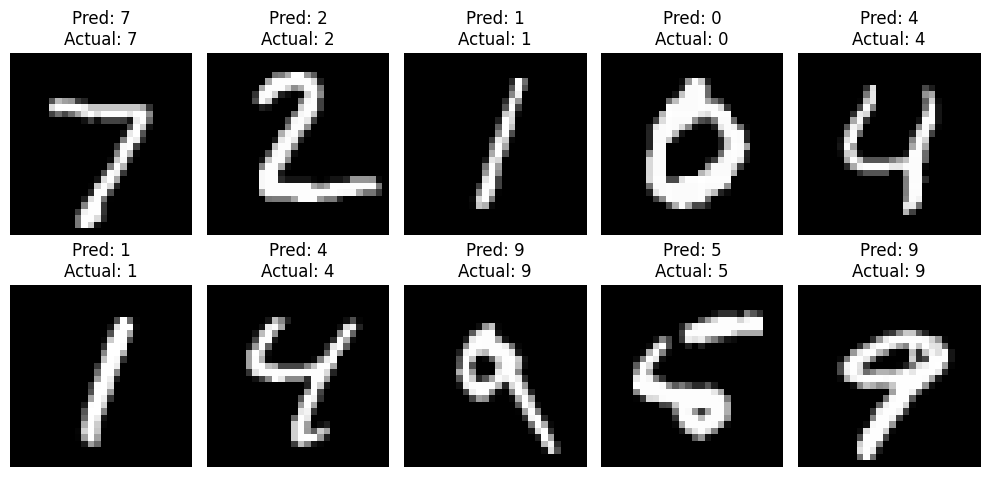

In [35]:
# Display sample predictions

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nActual: {actual_labels[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

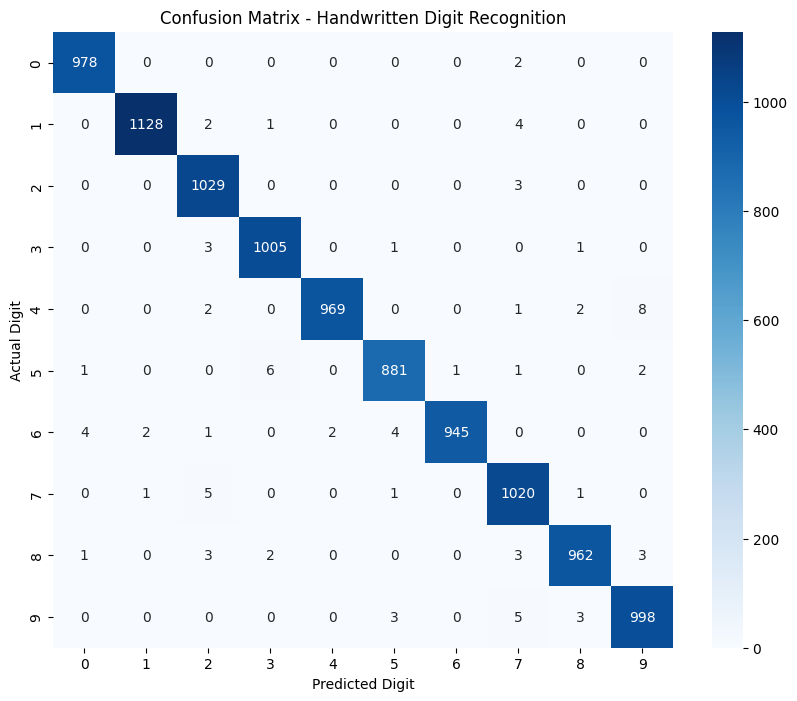

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(actual_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title('Confusion Matrix - Handwritten Digit Recognition')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


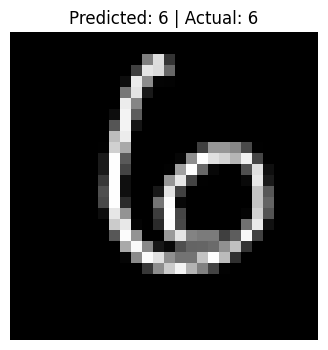

Predicted Digit: 6
Actual Digit: 6


In [37]:
# Select one test image
index = 100

image = X_test[index]
actual_digit = actual_labels[index]

# Predict the digit
prediction = model.predict(image.reshape(1, 28, 28, 1))
predicted_digit = np.argmax(prediction)

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_digit} | Actual: {actual_digit}")
plt.axis('off')
plt.show()

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", actual_digit)

In [38]:
# Save the trained model

model.save("handwritten_character_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [39]:
import os

print(os.listdir())

['.config', 'handwritten_character_cnn.keras', 'requirements.txt', 'README.md', 'sample_data']


In [40]:
!pip freeze > requirements.txt

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [41]:
import os

print(os.listdir())

['.config', 'handwritten_character_cnn.keras', 'requirements.txt', 'README.md', 'sample_data']


In [42]:
readme_content = """
# Handwritten Character Recognition using CNN

## Project Overview

This project uses a Convolutional Neural Network (CNN) to recognize handwritten digits using the MNIST dataset.

## Objective

The objective is to identify handwritten digits from 0 to 9 using image processing and deep learning techniques.

## Dataset

- Dataset: MNIST
- Training images: 60,000
- Testing images: 10,000
- Image size: 28 x 28 pixels
- Classes: 0 to 9

## Technologies Used

- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

## Model

The CNN model contains:

- Convolutional layers
- Max Pooling layers
- Flatten layer
- Dense layer
- Dropout layer
- Softmax output layer

## Evaluation

The model is evaluated using:

- Accuracy
- Loss
- Confusion Matrix
- Sample Predictions

## Future Scope

The project can be extended to recognize handwritten alphabets using the EMNIST dataset and complete words or sentences using sequence models such as CRNN, RNN, or LSTM.

## Conclusion

This project demonstrates the use of CNNs for accurate handwritten digit recognition using the MNIST dataset.
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [43]:
import os
print(os.listdir())

['.config', 'handwritten_character_cnn.keras', 'requirements.txt', 'README.md', 'sample_data']


In [45]:
from google.colab import files

files.download("handwritten_character_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>